In [1]:
import sys
sys.path.append('../src')
from eda import eda_summary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

raw_file = glob.glob('../data/raw/*.csv')[0]
print("Using:", raw_file)
df = pd.read_csv(raw_file)
df.head()

Using: ../data/raw/starter_data.csv


,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [2]:
df.info()
df.describe()
eda_summary(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


,column,dtype,missing,missing_pct,n_unique,mean,std,skew
0,category,object,0,0.0,3.0,NaN,NaN,NaN
1,value,int64,0,0.0,NaN,17.6,7.381659,0.819455
2,date,object,0,0.0,10.0,NaN,NaN,NaN


In [3]:
cat_cols = df.select_dtypes(exclude='number').columns
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- category ---
category
A    4
B    3
C    3
Name: count, dtype: int64

--- date ---
date
2025-08-01    1
2025-08-02    1
2025-08-03    1
2025-08-04    1
2025-08-05    1
2025-08-06    1
2025-08-07    1
2025-08-08    1
2025-08-09    1
2025-08-10    1
Name: count, dtype: int64


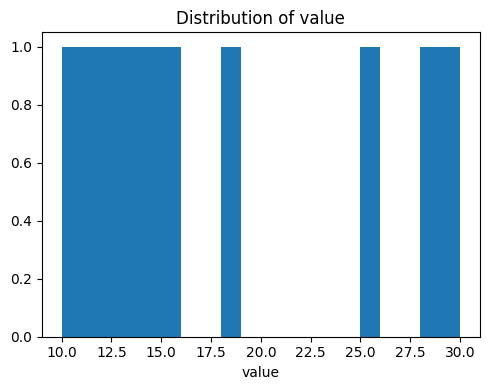

In [4]:
numeric_cols = df.select_dtypes(include='number').columns[:3]  # first 3 numeric cols

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 4))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    ax.hist(df[col].dropna(), bins=20)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

In [5]:
if len(numeric_cols) >= 2:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]], alpha=0.5)
    plt.xlabel(numeric_cols[0])
    plt.ylabel(numeric_cols[1])
    plt.title(f'{numeric_cols[0]} vs {numeric_cols[1]}')
    plt.show()

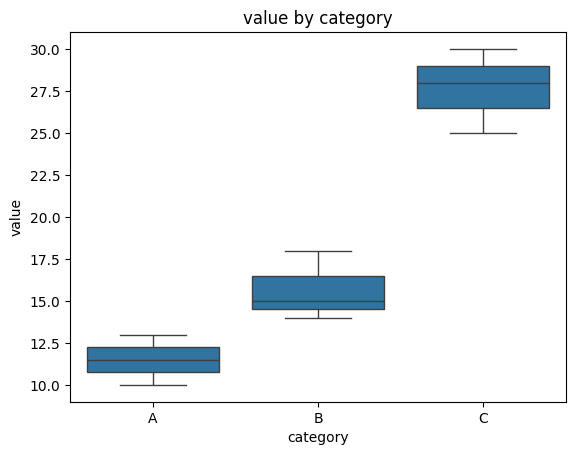

In [6]:
if len(cat_cols) > 0:
    sns.boxplot(data=df, x=cat_cols[0], y=numeric_cols[0])
    plt.title(f'{numeric_cols[0]} by {cat_cols[0]}')
    plt.show()

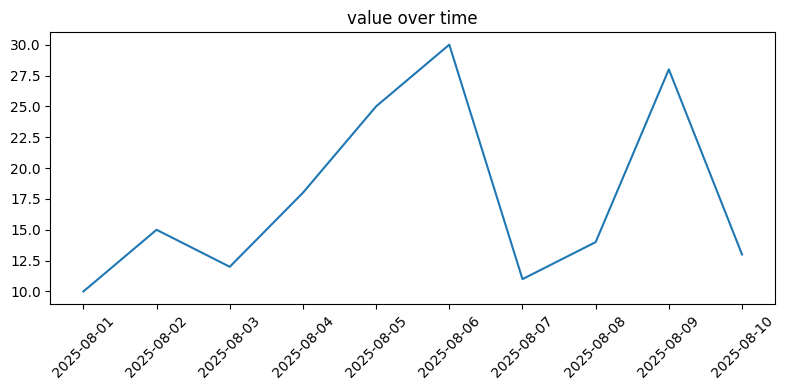

In [7]:
date_cols = [c for c in df.columns if 'date' in c.lower()]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]])
    df_sorted = df.sort_values(date_cols[0])
    plt.figure(figsize=(8, 4))
    plt.plot(df_sorted[date_cols[0]], df_sorted[numeric_cols[0]])
    plt.title(f'{numeric_cols[0]} over time')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

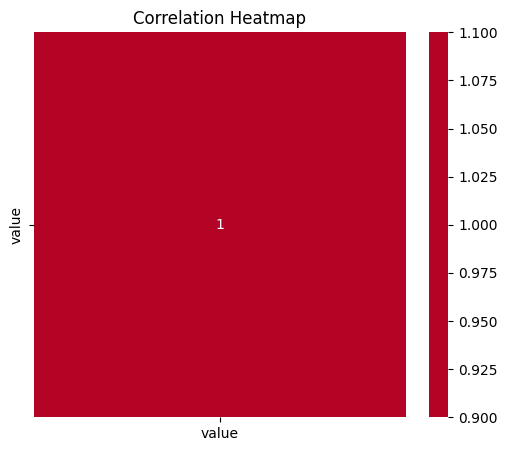

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()